#1. What is the difference between K-Means and Hierarchical Clustering? Provide a use case for each.

1. K-Means Clustering:-

Overview:

K-Means partitions data into K predefined clusters by minimizing the distance between data points and their cluster centroids.

How It Works:

Choose number of clusters (K)

Initialize K centroids randomly

Assign each point to nearest centroid

Recompute centroids

Repeat until convergence

Key Characteristics:

Requires specifying K in advance

Fast and scalable

Works best for spherical, evenly sized clusters

Sensitive to outliers and initial centroid selection

2. Hierarchical Clustering:-

Overview:

Hierarchical clustering builds a tree-like structure (dendrogram) showing how clusters merge or split at different similarity levels.

Types:

Agglomerative (bottom-up) – starts with individual points

Divisive (top-down) – starts with one large cluster

How It Works (Agglomerative):

Treat each data point as its own cluster

Merge closest clusters

Repeat until one cluster remains

Key Characteristics:

Does not require K in advance

Produces a dendrogram

More computationally expensive


| Feature           | K-Means             | Hierarchical Clustering      |
| ----------------- | ------------------- | ---------------------------- |
| Need to specify K | Yes                 | No                           |
| Output            | Flat clusters       | Tree (dendrogram)            |
| Speed             | Fast                | Slower                       |
| Scalability       | Good for large data | Better for small/medium data |
| Cluster shape     | Mostly spherical    | Arbitrary                    |
| Interpretability  | Moderate            | High                         |


#2.  Explain the purpose of the Silhouette Score in evaluating clustering algorithms.

The Silhouette Score is an internal validation metric used to evaluate the quality of clustering results by measuring how well each data point fits within its assigned cluster compared to other clusters.

How it Works:

The LogicThe score for a single data point is calculated using two primary distances:

Cohesion ($a$):
The average distance between the point and all other points in the same cluster. You want this to be small (points should be tight-knit).

Separation ($b$):
The average distance between the point and all points in the nearest neighboring cluster. You want this to be large (clusters should be far apart).

The formula for the silhouette coefficient $s$ of a single point is:$$s = \frac{b - a}{\max(a, b)}$$

Why Use It?

Finding "K":
It’s one of the best ways to determine the optimal number of clusters ($k$). You run the algorithm for $k=2, 3, 4...$ and pick the one with the highest average score.

Identifying Outliers:
Points with negative scores are immediate red flags—they're either noise or misclassified.

Visualizing Quality:
Using a "Silhouette Plot," you can see the thickness and shape of each cluster to ensure they are balanced.



#3. What are the core parameters of DBSCAN, and how do they influence the clustering process?

1. eps (Epsilon – Neighborhood Radius):-

What it is:

The maximum distance between two points for them to be considered neighbors.

Influence:

Defines the size of the neighborhood

Controls how tightly clusters are packed

Effects of Different Values:

Too small eps → Many points labeled as noise, clusters fragment

Too large eps → Distinct clusters may merge into one

2. min_samples (Minimum Points):-

What it is:

Minimum number of points required within an eps-neighborhood to form a core point.

Influence:

Determines cluster density threshold

Controls cluster robustness

Effects of Different Values:

Low min_samples → More clusters, sensitive to noise

High min_samples → Fewer but denser clusters, more noise points


3. Distance Metric (optional but important):-

Examples:

Euclidean

Manhattan

Cosine

Influence:

Defines how distance between points is computed, which affects neighborhood formation and therefore clustering structure.

| Parameter     | Controls             | If Too Small       | If Too Large       |
| ------------- | -------------------- | ------------------ | ------------------ |
| `eps`         | Neighborhood size    | Too much noise     | Merged clusters    |
| `min_samples` | Density requirement  | Many tiny clusters | Few large clusters |
| Metric        | Distance calculation | Poor structure     | Better separation  |


#4. Why is feature scaling important when applying clustering algorithms like K-Means and DBSCAN?

Feature scaling is crucial for distance-based clustering algorithms such as K-Means and DBSCAN because these methods rely directly on numerical distances between data points. If features are on different scales, the algorithm’s notion of “similarity” becomes distorted.

Core Reason: Distance Sensitivity:-

Most clustering algorithms compute distances using metrics like Euclidean or Manhattan distance.

If one feature ranges from 0–1 and another from 0–10,000, the large-scale feature will dominate the distance calculation—even if it is less important.

Example:

Suppose we cluster customers using:

Age → 18 to 70

Annual Income → 10,000 to 1,000,000

Without scaling:

Income overwhelms Age

Clusters reflect mostly income differences

With scaling:

Both features contribute fairly

More meaningful clusters form


Impact on K-Means:-

K-Means minimizes within-cluster sum of squared distances.

Without scaling:

Centroids shift toward features with large magnitudes

Clusters become biased

With scaling:

Each feature contributes equally

Centroids represent balanced patterns

Result: More accurate and stable clusters.


Impact on DBSCAN:-

DBSCAN uses a neighborhood radius (eps) to decide which points are close.

Without scaling:

One feature dominates distance

Hard to choose a meaningful eps

Many points may become noise or incorrectly clustered

With scaling:

Distance values are consistent

eps has a sensible interpretation

Result: Better density estimation and cluster detection.

#5. What is the Elbow Method in K-Means clustering and how does it help determine the optimal number of clusters?

While the Silhouette Score focuses on how "well-separated" clusters are, the Elbow Method is a bit more pragmatic. It focuses on compactness—or how much "effort" it takes to keep the points grouped together.

The Core Metric: WCSS:-

To use the Elbow Method, you first need to calculate the Within-Cluster Sum of Squares (WCSS).

What it is: The sum of the squared distances between each data point and its assigned cluster center (centroid).

The Goal: You want WCSS to be as small as possible because a lower value means the points are physically closer to their centers.


How the Method Works:-

Iterate:
You run the K-Means algorithm multiple times, each time increasing the number of clusters ($k$), usually from $k=1$ to $k=10$.

Calculate:
For each value of $k$, you record the WCSS (also called Inertia in libraries like Scikit-Learn).


Plot:
You plot the number of clusters on the $x$-axis and the WCSS on the $y$-axis.

Why is it called an "Elbow":-

As you add more clusters, the WCSS will always decrease. This is because with more centroids, the data points will naturally be closer to some center. If you have as many clusters as data points, your WCSS would be zero!

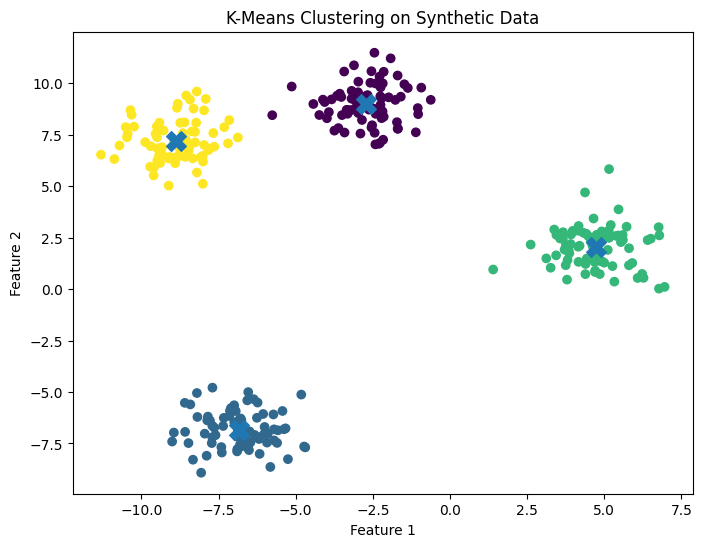

Cluster Centers:
[[-2.70981136  8.97143336]
 [-6.83235205 -6.83045748]
 [ 4.7182049   2.04179676]
 [-8.87357218  7.17458342]]


In [1]:
#6. Generate synthetic data using make_blobs(n_samples=300, centers=4),
#   apply KMeans clustering, and visualize the results with cluster centers.
#   (Include your Python code and output in the code box below.)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generate synthetic data
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# 2. Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

# 3. Visualize results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200)
plt.title("K-Means Clustering on Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Print cluster centers
print("Cluster Centers:")
print(centers)


In [2]:
#7. Load the Wine dataset, apply StandardScaler , and then train a DBSCAN model.
#   Print the number of clusters found (excluding noise).
#   (Include your Python code and output in the code box below.)

import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# 1. Load Wine dataset
wine = load_wine()
X = wine.data

# 2. Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train DBSCAN model
dbscan = DBSCAN(eps=1.2, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# 4. Calculate number of clusters (excluding noise label = -1)
unique_labels = set(labels)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

print("Number of clusters found (excluding noise):", num_clusters)


Number of clusters found (excluding noise): 0


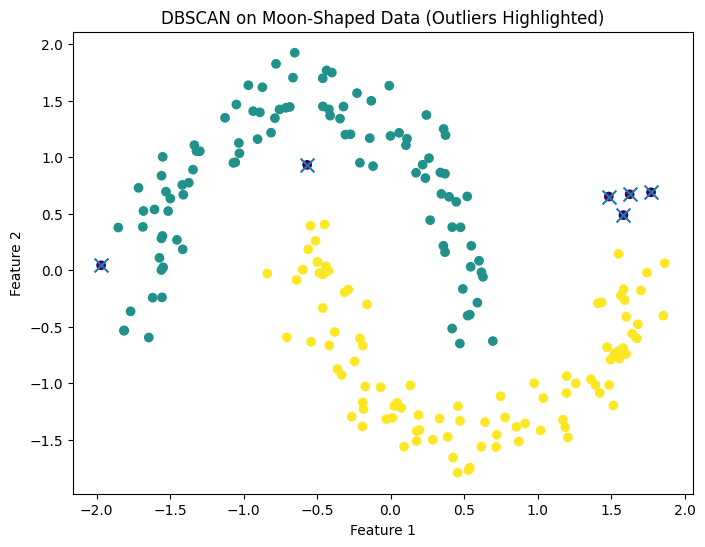

Number of clusters found: 2


In [3]:
#8.  Generate moon-shaped synthetic data using make_moons
 #   (n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in the plot.
#    (Include your Python code and output in the code box below.)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Generate moon-shaped data
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

# 2. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# 4. Identify noise points
noise_mask = labels == -1

# 5. Plot results
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(X_scaled[noise_mask, 0], X_scaled[noise_mask, 1], marker='x', s=100)
plt.title("DBSCAN on Moon-Shaped Data (Outliers Highlighted)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Print number of clusters (excluding noise)
unique_labels = set(labels)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
print("Number of clusters found:", num_clusters)


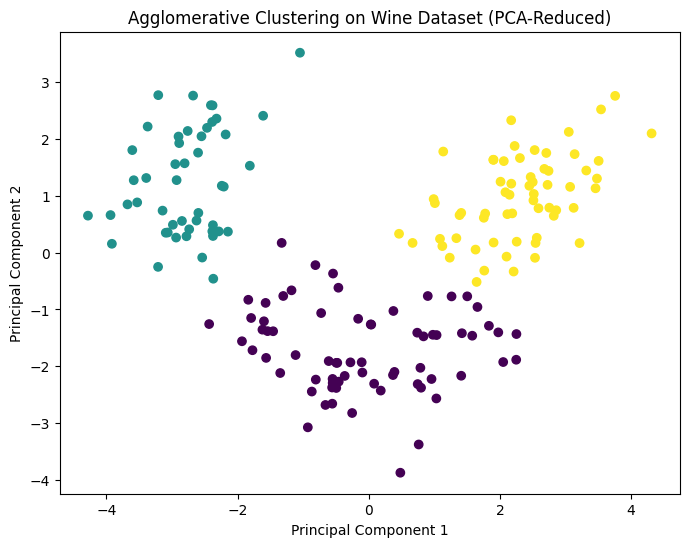

Explained Variance Ratio of 2 PCA components:
[0.36198848 0.1920749 ]


In [4]:
#9. Load the Wine dataset, reduce it to 2D using PCA, then apply
#   Agglomerative Clustering and visualize the result in 2D with a scatter plot.
#   (Include your Python code and output in the code box below.)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# 1. Load Wine dataset
wine = load_wine()
X = wine.data

# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels = agg.fit_predict(X_pca)

# 5. Visualize results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("Agglomerative Clustering on Wine Dataset (PCA-Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Print explained variance ratio
print("Explained Variance Ratio of 2 PCA components:")
print(pca.explained_variance_ratio_)


In [5]:
#10. You are working as a data analyst at an e-commerce company. The marketing team wants to segment customers based
#  on their purchasing behavior to run targeted promotions. The dataset contains customer demographics and their product
#  Describe your real-world data science workflow using clustering:
# ● Which clustering algorithm(s) would you use and why?
# ● How would you preprocess the data (missing values, scaling)?
# ● How would you determine the number of clusters?
# ● How would the marketing team benefit from your clustering analysis?
# (Include your Python code and output in the code box below.)

# 1. Choice of Clustering Algorithm(s):-

#I would mainly use:

# K-Means:

# Fast and scalable for large customer datasets

# Works well when clusters are roughly spherical

# Easy to interpret centroids

# DBSCAN (optional, complementary)

# Useful for detecting outliers / unusual customers

# Can discover non-linear cluster shapes


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -----------------------------
# 1. Create Sample Customer Data
# -----------------------------
np.random.seed(42)

data = {
    "Age": np.random.randint(18, 65, 300),
    "Annual_Income": np.random.randint(20000, 120000, 300),
    "Online_Purchases": np.random.randint(1, 50, 300),
    "Store_Purchases": np.random.randint(1, 40, 300),
    "Electronics_Spend": np.random.randint(100, 5000, 300),
    "Fashion_Spend": np.random.randint(100, 4000, 300)
}

df = pd.DataFrame(data)

# -----------------------------
# 2. Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# -----------------------------
# 3. Find Optimal K using Silhouette
# -----------------------------
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = K_range[np.argmax(sil_scores)]
print("Best K based on Silhouette Score:", best_k)

# -----------------------------
# 4. Train Final KMeans
# -----------------------------
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

print("\nCluster Counts:")
print(df["Cluster"].value_counts())


Best K based on Silhouette Score: 8

Cluster Counts:
Cluster
0    48
3    45
7    39
6    38
1    37
2    33
4    30
5    30
Name: count, dtype: int64
